# Модель SIR в виде сети Петри: базовый прогон

Модель эпидемии SIR описывается сетью Петри с тремя позициями
($S$ --- восприимчивые, $I$ --- инфицированные, $R$ --- выздоровевшие)
и двумя переходами: заражение $S + I \to 2I$ со скоростью $\beta$
и выздоровление $I \to R$ со скоростью $\gamma$.
В этом скрипте выполняется один прогон модели двумя способами:
детерминированным и стохастическим.

## Активация проекта и загрузка пакетов

Модуль `SIRPetri` с кодом модели лежит в каталоге `src`.
Проверка `@isdefined` нужна, чтобы модуль не загружался повторно,
когда несколько скриптов выполняются в одном сеансе.

In [1]:
using DrWatson
@quickactivate "project"
using Random
@isdefined(SIRPetri) || include(srcdir("SIRPetri.jl"))
using .SIRPetri
using DataFrames, CSV, Plots

script_name = "sirpetri_run"
mkpath(plotsdir())
mkpath(datadir())

"/home/iaberezhnoy/work/study/2026-1/2026-1==study--simulation-modeling/2026-1--study--simulation-modeling/labs/lab06/project/data"

## Параметры модели

In [2]:
β = 0.3
γ = 0.1
tmax = 100.0

100.0

## Построение сети

Функция возвращает саму сеть, начальную маркировку
($S = 990$, $I = 10$, $R = 0$) и имена позиций.

In [3]:
net, u0, states = build_sir_network(β, γ)
u0

3-element Vector{Float64}:
 990.0
  10.0
   0.0

## Детерминированная симуляция

По сети строится система дифференциальных уравнений,
которая решается методом Tsit5.

In [4]:
df_det = simulate_deterministic(net, u0, (0.0, tmax), saveat = 0.5, rates = [β, γ])
CSV.write(datadir("sir_det.csv"), df_det)
println("Пик I (детерминированная модель): ", round(maximum(df_det.I), digits = 2))
println("Время пика: ", df_det.time[argmax(df_det.I)])
println("Конечное R: ", round(df_det.R[end], digits = 2))

Пик I (детерминированная модель): 952.69
Время пика: 0.5
Конечное R: 999.95


## Стохастическая симуляция

Используется алгоритм Гиллеспи. Зерно генератора случайных чисел
зафиксировано, чтобы результат повторялся.

In [5]:
Random.seed!(123)
df_stoch = simulate_stochastic(net, u0, (0.0, tmax), rates = [β, γ])
CSV.write(datadir("sir_stoch.csv"), df_stoch)
println("Число событий: ", nrow(df_stoch) - 1)
println("Пик I (стохастическая модель): ", maximum(df_stoch.I))
println("Время последнего события: ", round(df_stoch.time[end], digits = 2))
println("Конечное R: ", df_stoch.R[end])

Число событий: 1990
Пик I (стохастическая модель): 999.0
Время последнего события: 64.35
Конечное R: 1000.0


## График детерминированной динамики

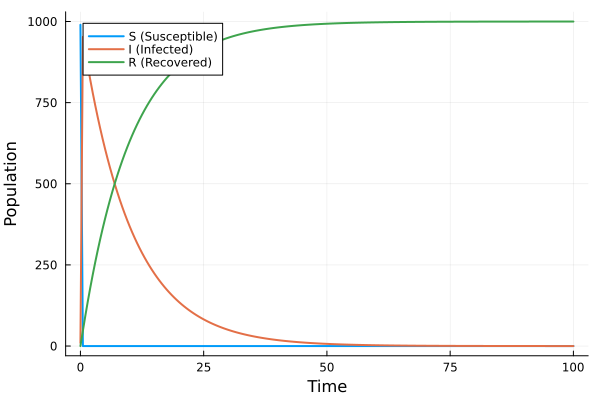

In [6]:
p_det = plot_sir(df_det)
savefig(p_det, plotsdir("sir_det_dynamics.png"))
p_det

## График стохастической динамики

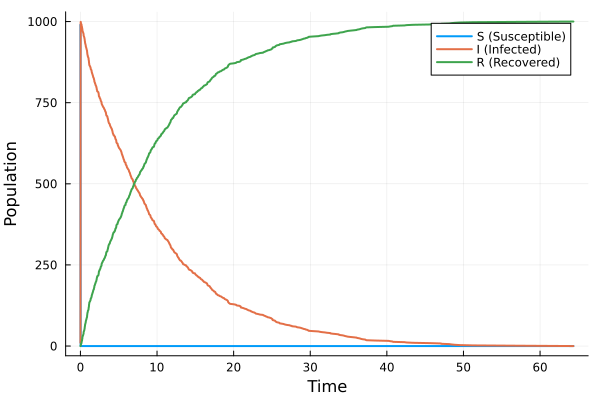

In [7]:
p_stoch = plot_sir(df_stoch)
savefig(p_stoch, plotsdir("sir_stoch_dynamics.png"))
p_stoch

## Итог

In [8]:
println("Базовый прогон завершён. Результаты в data/ и plots/")

Базовый прогон завершён. Результаты в data/ и plots/
